In [223]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

from football_prediction.data_loader import load_and_merge_data
from football_prediction.preprocessing import clean_match_data
from football_prediction.features import create_features, build_team_level_dataset
from football_prediction.model import (
    get_feature_columns,
    prepare_training_data,
    train_poisson_model,
    predict_match,

)

In [230]:
import importlib
import football_prediction.model as model_module
importlib.reload(model_module)
import numpy as np
import matplotlib.pyplot as plt
import football_prediction.model as model_module

In [199]:
from football_prediction.model import predict_match_full

In [200]:
from football_prediction.model import calculate_match_outcome_probabilities

In [201]:
from football_prediction.model import predict_match_full2


In [202]:
from football_prediction.model import poisson_pmf


In [203]:
raw_data = load_and_merge_data("../data/raw")
print(raw_data.shape)
raw_data.head()

(1900, 132)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,IWA,VCH,VCD,VCA,IWCH,IWCD,IWCA,VCCH,VCCD,VCCA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [204]:
clean_data = clean_match_data(raw_data)
print(clean_data.shape)
clean_data.head()

(1900, 6)


,date,home_team,away_team,home_goals,away_goals,result
0,16/08/2024,Man United,Fulham,1,0,H
1,17/08/2024,Ipswich,Liverpool,0,2,A
2,17/08/2024,Arsenal,Wolves,2,0,H
3,17/08/2024,Everton,Brighton,0,3,A
4,17/08/2024,Newcastle,Southampton,1,0,H


In [205]:
print(clean_data.columns.tolist())

['date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result']


In [206]:
featured_data = create_features(clean_data)
print(featured_data.shape)
featured_data.head()

(1900, 36)


,date,home_team,away_team,home_goals,away_goals,result,home_avg_goals_scored_last_3,home_avg_goals_conceded_last_3,home_avg_points_last_3,home_avg_goal_diff_last_3,...,away_avg_goals_scored_last_10,away_avg_goals_conceded_last_10,away_avg_points_last_10,away_avg_goal_diff_last_10,avg_home_goals_scored_last_5,avg_home_goals_conceded_last_5,avg_home_points_last_5,avg_away_goals_scored_last_5,avg_away_goals_conceded_last_5,avg_away_points_last_5
0,2020-09-12,Fulham,Arsenal,0,3,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-09-12,Crystal Palace,Southampton,1,0,H,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-09-12,Liverpool,Leeds,4,3,H,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-09-12,West Ham,Newcastle,0,2,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-09-13,West Brom,Leicester,0,3,A,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [207]:
team_model_df = build_team_level_dataset(featured_data)
print(team_model_df.shape)
team_model_df.head()

(3800, 32)


,date,team,opponent,goals,team_avg_goals_scored_last_3,team_avg_goals_scored_last_5,team_avg_goals_scored_last_10,team_avg_goals_conceded_last_3,team_avg_goals_conceded_last_5,team_avg_goals_conceded_last_10,...,opp_avg_points_last_3,opp_avg_points_last_5,opp_avg_points_last_10,opp_avg_goal_diff_last_3,opp_avg_goal_diff_last_5,opp_avg_goal_diff_last_10,venue_avg_goals_scored_last_5,venue_avg_goals_conceded_last_5,venue_avg_points_last_5,is_home
0,2020-09-12,Fulham,Arsenal,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2020-09-12,Arsenal,Fulham,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2020-09-12,Southampton,Crystal Palace,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2020-09-12,Leeds,Liverpool,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2020-09-12,Newcastle,West Ham,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [208]:
print(team_model_df.columns.tolist())

['date', 'team', 'opponent', 'goals', 'team_avg_goals_scored_last_3', 'team_avg_goals_scored_last_5', 'team_avg_goals_scored_last_10', 'team_avg_goals_conceded_last_3', 'team_avg_goals_conceded_last_5', 'team_avg_goals_conceded_last_10', 'team_avg_points_last_3', 'team_avg_points_last_5', 'team_avg_points_last_10', 'team_avg_goal_diff_last_3', 'team_avg_goal_diff_last_5', 'team_avg_goal_diff_last_10', 'opp_avg_goals_scored_last_3', 'opp_avg_goals_scored_last_5', 'opp_avg_goals_scored_last_10', 'opp_avg_goals_conceded_last_3', 'opp_avg_goals_conceded_last_5', 'opp_avg_goals_conceded_last_10', 'opp_avg_points_last_3', 'opp_avg_points_last_5', 'opp_avg_points_last_10', 'opp_avg_goal_diff_last_3', 'opp_avg_goal_diff_last_5', 'opp_avg_goal_diff_last_10', 'venue_avg_goals_scored_last_5', 'venue_avg_goals_conceded_last_5', 'venue_avg_points_last_5', 'is_home']


In [209]:
feature_cols = get_feature_columns()
print(feature_cols)

['team_avg_goals_scored_last_5', 'opp_avg_goals_scored_last_5', 'team_avg_points_last_5', 'opp_avg_points_last_5']


In [210]:
X, y = prepare_training_data(team_model_df)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (3762, 4)
y shape: (3762,)


,team_avg_goals_scored_last_5,opp_avg_goals_scored_last_5,team_avg_points_last_5,opp_avg_points_last_5
16,0.0,3.0,0.0,3.0
17,0.0,1.0,0.0,3.0
18,0.0,3.0,0.0,0.0
19,3.0,0.0,0.0,0.0
21,3.0,0.0,3.0,0.0


16    1
17    2
18    3
19    4
21    2
Name: goals, dtype: int64

In [211]:
model, X_train_full, y_train_full = train_poisson_model(team_model_df)

In [212]:
train_pred = model.predict(X_train_full)
mae = mean_absolute_error(y_train_full, train_pred)

print("Trainings-MAE:", mae)

Trainings-MAE: 1.0120247190695302


In [213]:
print("Features im Modell:")
print(list(model.feature_names_in_))

print("Features laut get_feature_columns():")
print(get_feature_columns())

print("Identisch?:", list(model.feature_names_in_) == get_feature_columns())

Features im Modell:
['team_avg_goals_scored_last_5', 'opp_avg_goals_scored_last_5', 'team_avg_points_last_5', 'opp_avg_points_last_5']
Features laut get_feature_columns():
['team_avg_goals_scored_last_5', 'opp_avg_goals_scored_last_5', 'team_avg_points_last_5', 'opp_avg_points_last_5']
Identisch?: True


In [214]:
result = predict_match(
    model=model,
    team_model_df=team_model_df,
    home_team="Arsenal",
    away_team="Chelsea",
)

result

{'home_team': 'Arsenal',
 'away_team': 'Chelsea',
 'predicted_home_goals': 1.406988518669389,
 'rounded_home_goals': 1}

In [215]:
print(f"Heimteam: {result['home_team']}")
print(f"Auswärtsteam: {result['away_team']}")
print(f"Vorhergesagte Heimtore: {result['predicted_home_goals']:.2f}")
print(f"Gerundete Heimtore: {result['rounded_home_goals']}")

Heimteam: Arsenal
Auswärtsteam: Chelsea
Vorhergesagte Heimtore: 1.41
Gerundete Heimtore: 1


In [216]:
home_df = team_model_df[team_model_df["is_home"] == 1]
away_df = team_model_df[team_model_df["is_home"] == 0]

home_model, X_home, y_home = train_poisson_model(home_df)
away_model, X_away, y_away = train_poisson_model(away_df)

In [217]:
result = predict_match_full(
    home_model=home_model,
    away_model=away_model,
    team_model_df=team_model_df,
    home_team="Arsenal",
    away_team="Chelsea",
)

print(result)

{'home_team': 'Arsenal', 'away_team': 'Chelsea', 'predicted_home_goals': 1.5199101504708277, 'predicted_away_goals': 1.3439136880398959, 'rounded_home_goals': 2, 'rounded_away_goals': 1, 'winner': 'Arsenal'}


In [218]:
result = predict_match_full(
    home_model=home_model,
    away_model=away_model,
    team_model_df=team_model_df,
    home_team="Arsenal",
    away_team="Chelsea",
)

print(result)

{'home_team': 'Arsenal', 'away_team': 'Chelsea', 'predicted_home_goals': 1.5199101504708277, 'predicted_away_goals': 1.3439136880398959, 'rounded_home_goals': 2, 'rounded_away_goals': 1, 'winner': 'Arsenal'}


In [219]:
print(f"{result['home_team']} vs {result['away_team']}")
print(f"Erwartet: {result['predicted_home_goals']:.2f} : {result['predicted_away_goals']:.2f}")
print(f"Ergebnis: {result['rounded_home_goals']} : {result['rounded_away_goals']}")
print(f"Sieger: {result['winner']}")

Arsenal vs Chelsea
Erwartet: 1.52 : 1.34
Ergebnis: 2 : 1
Sieger: Arsenal


In [220]:
result = predict_match_full2(
    home_model=home_model,
    away_model=away_model,
    team_model_df=team_model_df,
    home_team="Arsenal",
    away_team="Chelsea",
)

print(f"{result['home_team']} vs {result['away_team']}")
print(f"Erwartete Tore: {result['predicted_home_goals']:.2f} : {result['predicted_away_goals']:.2f}")
print(f"Gerundetes Ergebnis: {result['rounded_home_goals']} : {result['rounded_away_goals']}")
print(f"Sieger-Tipp: {result['winner']}")
print()
print(f"Wahrscheinlichkeit Heimsieg: {result['home_win_probability']:.2%}")
print(f"Wahrscheinlichkeit Unentschieden: {result['draw_probability']:.2%}")
print(f"Wahrscheinlichkeit Auswärtssieg: {result['away_win_probability']:.2%}")

Arsenal vs Chelsea
Erwartete Tore: 1.52 : 1.34
Gerundetes Ergebnis: 2 : 1
Sieger-Tipp: Arsenal

Wahrscheinlichkeit Heimsieg: 41.52%
Wahrscheinlichkeit Unentschieden: 24.85%
Wahrscheinlichkeit Auswärtssieg: 33.63%


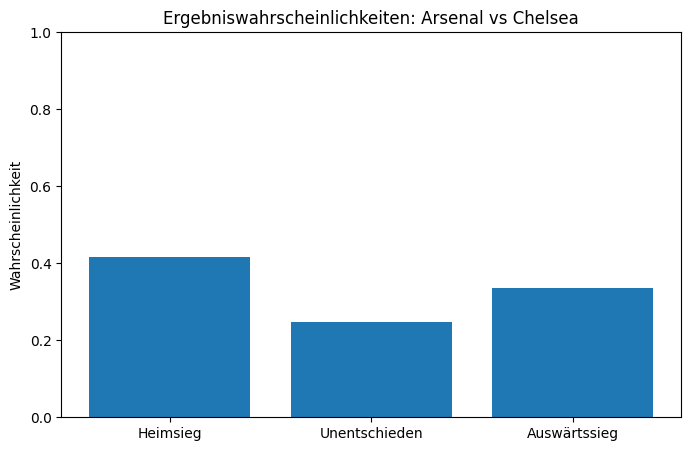

In [231]:
labels = ["Heimsieg", "Unentschieden", "Auswärtssieg"]
values = [
    result["home_win_probability"],
    result["draw_probability"],
    result["away_win_probability"],
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.ylabel("Wahrscheinlichkeit")
plt.ylim(0, 1)
plt.title(f"Ergebniswahrscheinlichkeiten: {result['home_team']} vs {result['away_team']}")
plt.show()

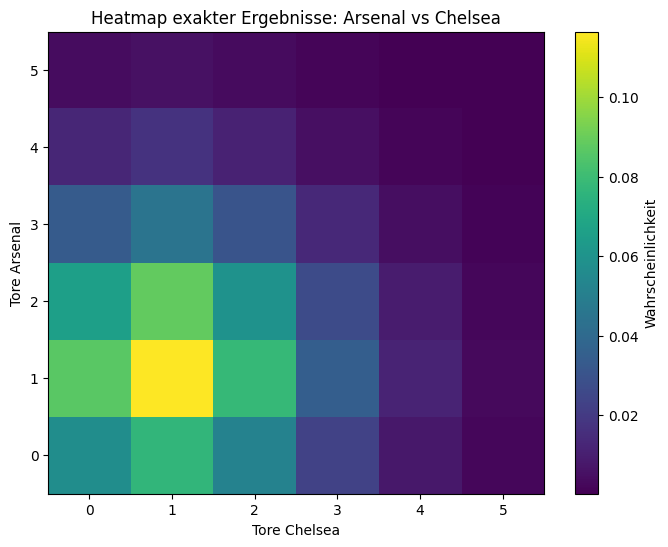

In [232]:
max_goals_plot = 5
score_matrix = np.zeros((max_goals_plot + 1, max_goals_plot + 1))

for (home_goals, away_goals), prob in result["score_probabilities"].items():
    if home_goals <= max_goals_plot and away_goals <= max_goals_plot:
        score_matrix[home_goals, away_goals] = prob

plt.figure(figsize=(8, 6))
plt.imshow(score_matrix, origin="lower", aspect="auto")
plt.colorbar(label="Wahrscheinlichkeit")
plt.xticks(range(max_goals_plot + 1))
plt.yticks(range(max_goals_plot + 1))
plt.xlabel(f"Tore {result['away_team']}")
plt.ylabel(f"Tore {result['home_team']}")
plt.title(f"Heatmap exakter Ergebnisse: {result['home_team']} vs {result['away_team']}")
plt.show()

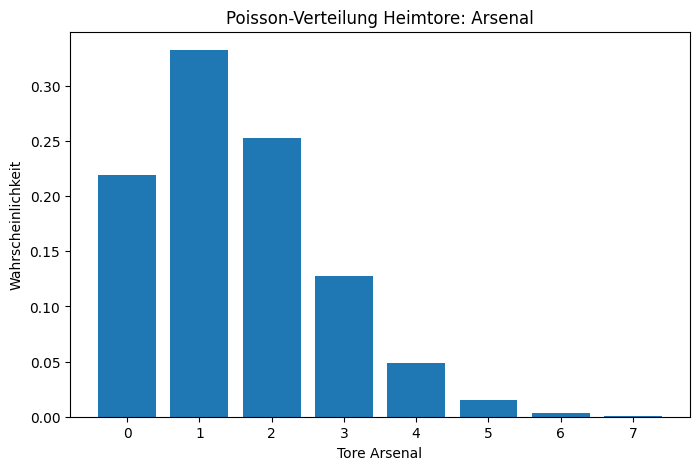

In [233]:
home_lambda = result["predicted_home_goals"]
goals = list(range(0, 8))
home_probs = [model_module.poisson_pmf(k, home_lambda) for k in goals]

plt.figure(figsize=(8, 5))
plt.bar(goals, home_probs)
plt.xlabel(f"Tore {result['home_team']}")
plt.ylabel("Wahrscheinlichkeit")
plt.title(f"Poisson-Verteilung Heimtore: {result['home_team']}")
plt.xticks(goals)
plt.show()

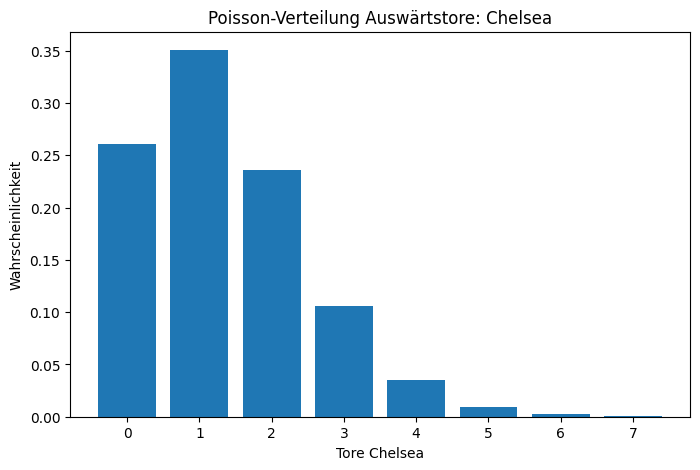

In [234]:
away_lambda = result["predicted_away_goals"]
goals = list(range(0, 8))
away_probs = [model_module.poisson_pmf(k, away_lambda) for k in goals]

plt.figure(figsize=(8, 5))
plt.bar(goals, away_probs)
plt.xlabel(f"Tore {result['away_team']}")
plt.ylabel("Wahrscheinlichkeit")
plt.title(f"Poisson-Verteilung Auswärtstore: {result['away_team']}")
plt.xticks(goals)
plt.show()